# Dreaddit EDA 

## 1. Setup

In [6]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency, mannwhitneyu


warnings.filterwarnings('ignore')

OUTPUT_DIR = '../../../reports/c3_text_stressor_distortion/Stress header/eda_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

LABEL_NAMES = {0: 'Not Stressed', 1: 'Stressed'}
LABEL_ORDER = ['Not Stressed', 'Stressed']
LABEL_COLORS = {'Not Stressed': '#2E75B6', 'Stressed': '#C00000'}
from sklearn.feature_extraction.text import CountVectorizer


## 2. Load Dataset

In [7]:
TRAIN_PATH = '../../../data/Stress header/raw/Dreaddit/train-00000-of-00001.parquet' 
TEST_PATH = '../../../data/Stress header/raw/Dreaddit/test-00000-of-00001.parquet'

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print(f'Train shape: {train_df.shape}')
print(f'Test shape : {test_df.shape}')
display(train_df.head())

Train shape: (2838, 116)
Test shape : (715, 116)


,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.125,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1535935605,2,7.769821,...,1.000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",239,1,0.6,1516429555,0,2.667798,...,1.000,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5,4.104027,0.141671
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1421,1,0.8,1539809005,24,7.554238,...,1.000,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1,7.910952,-0.204167


In [8]:
print(train_df.columns.tolist())

['subreddit', 'post_id', 'sentence_range', 'text', 'id', 'label', 'confidence', 'social_timestamp', 'social_karma', 'syntax_ari', 'lex_liwc_WC', 'lex_liwc_Analytic', 'lex_liwc_Clout', 'lex_liwc_Authentic', 'lex_liwc_Tone', 'lex_liwc_WPS', 'lex_liwc_Sixltr', 'lex_liwc_Dic', 'lex_liwc_function', 'lex_liwc_pronoun', 'lex_liwc_ppron', 'lex_liwc_i', 'lex_liwc_we', 'lex_liwc_you', 'lex_liwc_shehe', 'lex_liwc_they', 'lex_liwc_ipron', 'lex_liwc_article', 'lex_liwc_prep', 'lex_liwc_auxverb', 'lex_liwc_adverb', 'lex_liwc_conj', 'lex_liwc_negate', 'lex_liwc_verb', 'lex_liwc_adj', 'lex_liwc_compare', 'lex_liwc_interrog', 'lex_liwc_number', 'lex_liwc_quant', 'lex_liwc_affect', 'lex_liwc_posemo', 'lex_liwc_negemo', 'lex_liwc_anx', 'lex_liwc_anger', 'lex_liwc_sad', 'lex_liwc_social', 'lex_liwc_family', 'lex_liwc_friend', 'lex_liwc_female', 'lex_liwc_male', 'lex_liwc_cogproc', 'lex_liwc_insight', 'lex_liwc_cause', 'lex_liwc_discrep', 'lex_liwc_tentat', 'lex_liwc_certain', 'lex_liwc_differ', 'lex_liwc_

## 3. Feature Engineering

These features are easy to explain in a report and useful for understanding how stressed and non-stressed posts differ.

In [9]:
def add_simple_text_features(df):
    df = df.copy()
    df['text'] = df['text'].fillna('').astype(str)

    if 'label' in df.columns:
        df['label_name'] = df['label'].map(LABEL_NAMES)

    words = df['text'].str.split()

    df['text_length'] = df['text'].str.len()
    df['word_count'] = words.apply(len)
    df['avg_word_len'] = words.apply(lambda tokens: np.mean([len(w) for w in tokens]) if tokens else 0)
    df['sentence_count'] = df['text'].apply(lambda x: max(1, len(re.findall(r'[.!?]+', x))))
    df['question_count'] = df['text'].str.count(r'\?')
    df['exclaim_count'] = df['text'].str.count('!')
    df['capital_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
    df['unique_words'] = words.apply(lambda tokens: len(set(w.lower() for w in tokens)))
    df['lexical_diversity'] = np.where(df['word_count'] > 0, df['unique_words'] / df['word_count'], 0)

    if 'sentiment' not in df.columns:
        df['sentiment'] = np.nan

    return df


train_df = add_simple_text_features(train_df)
test_df = add_simple_text_features(test_df)

simple_features = [
    'text_length', 'word_count', 'avg_word_len', 'sentence_count',
    'question_count', 'exclaim_count', 'capital_ratio',
    'unique_words', 'lexical_diversity', 'sentiment'
]

train_df[['text', 'label', 'label_name'] + simple_features].head()

,text,label,label_name,text_length,word_count,avg_word_len,sentence_count,question_count,exclaim_count,capital_ratio,unique_words,lexical_diversity,sentiment
0,"He said he had not felt that way before, sugge...",1,Stressed,571,113,4.061947,8,0,0,0.084063,90,0.796460,-0.002742
1,"Hey there r/assistance, Not sure if this is th...",0,Not Stressed,588,108,4.453704,4,0,0,0.037415,85,0.787037,0.292857
2,My mom then hit me with the newspaper and it s...,1,Stressed,847,166,4.108434,5,1,0,0.012987,109,0.656627,0.011894
3,"until i met my new boyfriend, he is amazing, h...",1,Stressed,1277,273,3.681319,5,0,0,0.009397,129,0.472527,0.141671
4,October is Domestic Violence Awareness Month a...,1,Stressed,533,89,5.000000,5,0,0,0.024390,72,0.808989,-0.204167


## 4. Dataset Overview

This section answers basic research questions such as dataset size, missing values, duplicates, and sample records.

In [10]:
overview = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'Rows': [len(train_df), len(test_df)],
    'Columns': [train_df.shape[1], test_df.shape[1]],
    'Missing Values': [train_df.isna().sum().sum(), test_df.isna().sum().sum()],
    'Duplicate Texts': [train_df['text'].duplicated().sum(), test_df['text'].duplicated().sum()]
})

display(overview)

missing_summary = train_df.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

if len(missing_summary) > 0:
    print('Missing values in train dataset:')
    display(missing_summary.to_frame('missing_count'))
else:
    print('No missing values found in the train dataset.')

,Dataset,Rows,Columns,Missing Values,Duplicate Texts
0,Train,2838,126,0,18
1,Test,715,126,0,0


No missing values found in the train dataset.


In [11]:
sample_cols = ['subreddit', 'label', 'label_name', 'text']

examples = (
    train_df[sample_cols]
    .groupby('label_name', group_keys=False)
    .sample(n=2, random_state=42)
)

display(examples)

,subreddit,label,label_name,text
614,homeless,0,Not Stressed,So many local counties and cities struggle wit...
2153,anxiety,0,Not Stressed,Today I made the choice to go sign up for a gy...
790,relationships,1,Stressed,"But, for now, and until I'm on the proper road..."
2491,relationships,1,Stressed,"We've been getting along very well, and our pr..."


In [12]:
lex_emotion_column_df = train_df[['lex_liwc_anx','lex_liwc_sad','lex_liwc_anger','lex_liwc_negemo','lex_liwc_affect','label']]
lex_emotion_column_df.head()

,lex_liwc_anx,lex_liwc_sad,lex_liwc_anger,lex_liwc_negemo,lex_liwc_affect,label
0,0.86,3.45,2.59,6.90,8.62,1
1,0.00,0.00,0.00,0.00,5.50,0
2,0.00,0.00,0.00,1.20,2.40,1
3,0.00,0.73,0.37,2.93,8.79,1
4,1.12,0.00,4.49,7.87,7.87,1


**lex_liwc_anx** (*Anxiety*): Measures words related to fear and worry (e.g., *"worried," "fearful," "nervous"*). The mental illness domains in the dataset (anxiety and PTSD) showed higher coverage in this category compared to the financial domain.

**lex_liwc_sad** (*Sadness*): Captures words expressing grief or sorrow (e.g., *"crying," "depressed"*).

**lex_liwc_anger** (*Anger*): Identifies words associated with frustration or hostility (e.g., *"hate," "annoyed"*).

**lex_liwc_negemo** (*Negative Emotions*): An umbrella category that includes anxiety, sadness, and anger. The paper highlights that stressful data typically contains a significantly higher percentage of *negemo* words (3.54%) compared to non-stressful data (1.75%).

**lex_liwc_affect** (*Affective Processes*): A broad category representing words related to emotions and feelings in general, covering both positive and negative states.

In [13]:
lex_cognitive_column_df = train_df[['lex_liwc_cogproc','lex_liwc_tentat','lex_liwc_negate','lex_liwc_certain','lex_liwc_discrep','label']]
lex_cognitive_column_df.head()

,lex_liwc_cogproc,lex_liwc_tentat,lex_liwc_negate,lex_liwc_certain,lex_liwc_discrep,label
0,11.21,5.17,1.72,0.00,2.59,1
1,11.93,5.50,0.92,1.83,3.67,0
2,10.18,2.99,1.20,0.00,0.60,1
3,16.85,1.83,3.66,1.47,1.83,1
4,11.24,0.00,2.25,1.12,0.00,1


**lex_liwc_cogproc** (*Cognitive Processes*): This is the master category that encompasses the others listed below. It tracks words associated with thinking, determining causes, and organizing thoughts (e.g., *"cause," "know," "think"*).

**lex_liwc_tentat** (*Tentativeness*): Measures words that express uncertainty or hesitation (e.g., *"maybe," "perhaps," "guess"*). High scores here often correlate with the definition of stress used in the paper: a state of *"uncertainty"* regarding one's ability to handle demanding circumstances.

**lex_liwc_negate** (*Negations*): Tracks words like *"no," "not,"* or *"never."* The researchers noted that stressful text tends to be more complex, and negations are a key part of how users frame their inability to cope or the absence of support.

**lex_liwc_certain** (*Certainty*): Identifies words expressing absolute conviction (e.g., *"always," "never," "completely"*).

**lex_liwc_discrep** (*Discrepancies*): Measures words that indicate a gap between reality and expectation (e.g., *"should," "would," "could"*).

In [14]:
lex_risk_severity_column_df = train_df[['lex_liwc_death','lex_liwc_risk','lex_liwc_health','label']]
lex_risk_severity_column_df.head()

,lex_liwc_death,lex_liwc_risk,lex_liwc_health,label
0,0.0,2.59,1.72,1
1,0.0,0.00,0.00,0
2,0.0,0.00,0.00,1
3,0.0,0.73,0.00,1
4,0.0,1.12,1.12,1


**lex_liwc_death** (*Death*): This category tracks words related to mortality and the end of life (e.g., *"bury," "coffin," "kill," "die"*). In a stress dataset, high scores in this column can flag severe trauma, particularly in the PTSD and Abuse domains where users may be discussing past life-threatening events.

**lex_liwc_risk** (*Risk*): This identifies language associated with danger or potential harm (e.g., *"danger," "safe," "prevent," "caution"*). Because the paper defines stress as a *"reaction to extant and future demands and pressures"* that can be threatening, this column acts as a direct proxy for that sense of threat.

**lex_liwc_health** (*Health*): This category includes words related to physical and mental well-being (e.g., *"clinic," "flu," "doctor," "medicine"*). The researchers noted that many users, especially in the anxiety and PTSD subreddits, frequently discuss medical symptoms, hospital visits, and therapy as part of their stressful experiences.

In [15]:
lex_Linguistic_column_df = train_df[['lex_liwc_i','lex_liwc_focuspast','lex_liwc_focuspresent','syntax_ari','label']]
lex_Linguistic_column_df.head()

,lex_liwc_i,lex_liwc_focuspast,lex_liwc_focuspresent,syntax_ari,label
0,9.48,4.31,11.21,1.806818,1
1,1.83,0.92,13.76,9.429737,0
2,8.98,3.59,14.37,7.769821,1
3,16.12,7.69,13.19,2.667798,1
4,7.87,5.62,6.74,7.554238,1


**lex_liwc_i** (*First-Person Pronouns*): This measures the use of "I," "me," and "my". The researchers found that stressful data uses significantly more first-person pronouns (9.81%) compared to non-stressful data (6.53%). This likely reflects the "increased self-focus" typical of someone experiencing mental or emotional strain.

**lex_liwc_focuspast** (*Past Focus*): This tracks the use of past-tense verbs. The paper notes that writers often use the past tense to frame negative or traumatic experiences retrospectively, which can sometimes lead to misclassification if the model doesn't understand the temporal context.

**lex_liwc_focuspresent** (*Present Focus*): This tracks present-tense verbs. The authors suggest that stress is a reaction to "extant and future demands," so focusing on the present often indicates the user is currently "ruminating" or dealing with an active crisis.

**syntax_ari** (*Automated Readability Index*): This is a syntactic feature that gauges the difficulty of the text. Interestingly, the study found that while stressful posts are often longer and more syntactically complex (having more clauses per sentence), they are sometimes rated as "simpler" by the ARI.

In [16]:
lex_dal_emotion_dimensions_column_df = train_df[['lex_dal_avg_pleasantness','lex_dal_avg_activation','lex_dal_min_pleasantness','label']]
lex_dal_emotion_dimensions_column_df.head()

,lex_dal_avg_pleasantness,lex_dal_avg_activation,lex_dal_min_pleasantness,label
0,1.89556,1.77000,1.000,1
1,1.88919,1.69586,1.125,0
2,1.85828,1.83088,1.000,1
3,1.98848,1.75356,1.000,1
4,1.81456,1.77644,1.000,1


**lex_dal_avg_pleasantness** (Pleasantness/Valence): This measures how "positive" or "negative" the words in the segment are on average. A low average pleasantness score is a strong indicator of the "negative attitude" required by the paper's definition of stress.

**lex_dal_avg_activation** (Activation/Arousal): This tracks the intensity or energy level of the language (e.g., "active" vs. "passive"). High activation often corresponds to acute stress or panic, while low activation might represent the "helplessness" or exhaustion described in some Reddit posts.

**lex_dal_min_pleasantness**: This identifies the "floor" of the emotional state by looking for the single most negative word in the segment. The researchers included minimum and maximum scores (not just averages) to capture extreme emotional spikes that might be diluted in a five-sentence average.

## 5. Class Balance Analysis

Class balance shows whether the dataset has similar numbers of stressed and non-stressed posts. This is important for understanding possible dataset bias.

,Count,Percentage
label_name,,
Not Stressed,1350,47.57
Stressed,1488,52.43


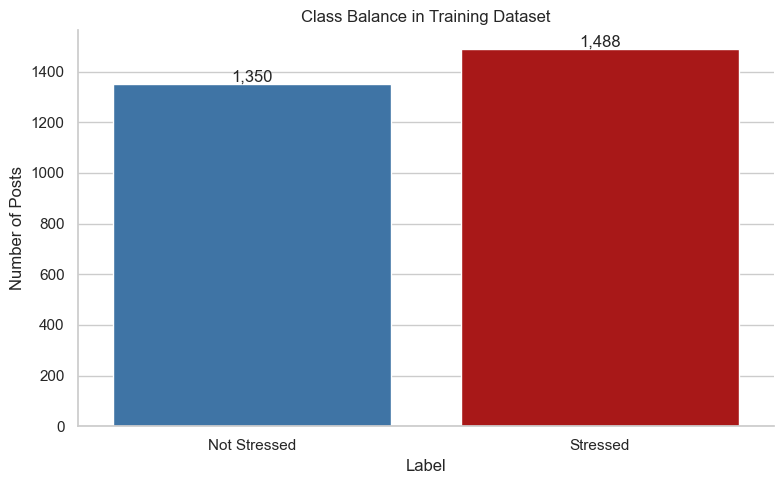

In [17]:
label_counts = train_df['label_name'].value_counts().reindex(LABEL_ORDER)
label_percent = (label_counts / label_counts.sum() * 100).round(2)

class_balance = pd.DataFrame({
    'Count': label_counts,
    'Percentage': label_percent
})

display(class_balance)

ax = sns.barplot(
    x=class_balance.index,
    y=class_balance['Count'],
    palette=[LABEL_COLORS[label] for label in class_balance.index]
)
ax.set_title('Class Balance in Training Dataset')
ax.set_xlabel('Label')
ax.set_ylabel('Number of Posts')

for i, value in enumerate(class_balance['Count']):
    ax.text(i, value, f'{value:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Subreddit Distribution

This shows how posts are distributed across subreddit categories and whether some categories contain more stressed posts.

,post_count
subreddit,
ptsd,584
relationships,552
anxiety,503
domesticviolence,316
assistance,289
survivorsofabuse,245
homeless,168
almosthomeless,80
stress,64


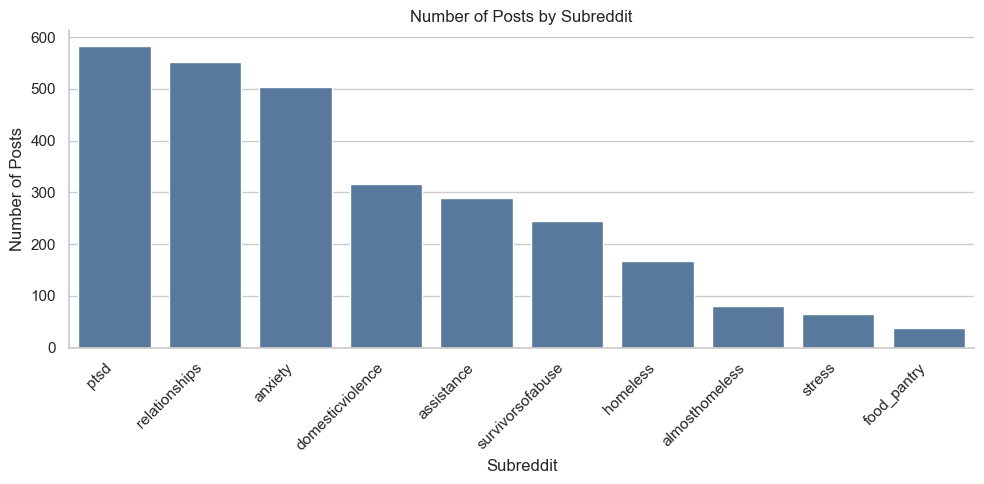

In [18]:
subreddit_counts = train_df['subreddit'].value_counts().to_frame('post_count')
display(subreddit_counts)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=subreddit_counts.index,
    y=subreddit_counts['post_count'],
    color='#4C78A8'
)
ax.set_title('Number of Posts by Subreddit')
ax.set_xlabel('Subreddit')
ax.set_ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/subreddit_counts.png', dpi=150, bbox_inches='tight')
plt.show()

label_name,Not Stressed,Stressed
subreddit,,
ptsd,252,332
anxiety,172,331
relationships,305,247
domesticviolence,114,202
survivorsofabuse,133,112
assistance,184,105
homeless,105,63
almosthomeless,33,47
stress,29,35


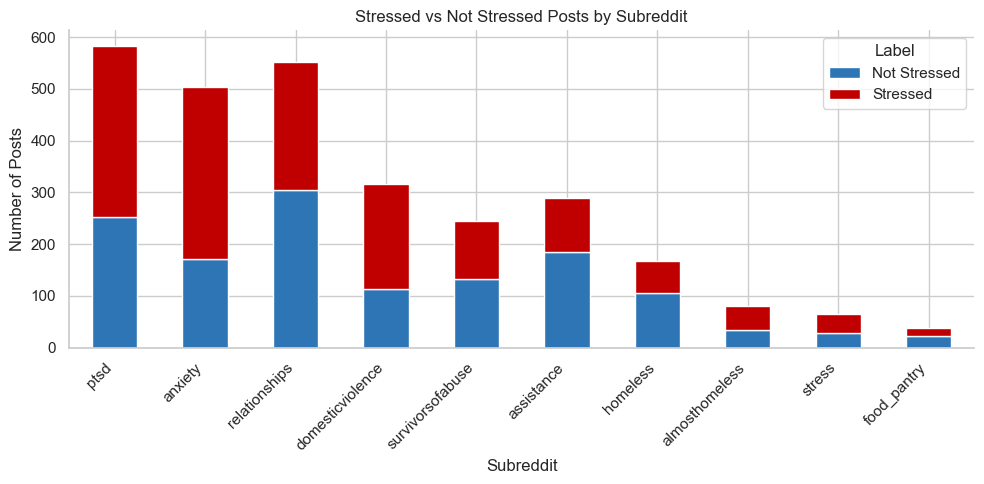

In [19]:
subreddit_label_counts = pd.crosstab(train_df['subreddit'], train_df['label_name'])
subreddit_label_counts = subreddit_label_counts.reindex(columns=LABEL_ORDER, fill_value=0)
subreddit_label_counts = subreddit_label_counts.sort_values('Stressed', ascending=False)

display(subreddit_label_counts)

ax = subreddit_label_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5),
    color=[LABEL_COLORS[label] for label in subreddit_label_counts.columns]
)
ax.set_title('Stressed vs Not Stressed Posts by Subreddit')
ax.set_xlabel('Subreddit')
ax.set_ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Label')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/subreddit_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Text Length and Writing Style

This section compares simple writing features between stressed and non-stressed posts.

In [20]:
length_features = ['text_length', 'word_count', 'avg_word_len', 'sentence_count', 'unique_words', 'lexical_diversity']

length_summary = (
    train_df.groupby('label_name')[length_features]
    .agg(['mean', 'median', 'std'])
    .round(2)
)

display(length_summary)

text_length                word_count               avg_word_len  \
                    mean median     std       mean median    std         mean   
label_name                                                                      
Not Stressed       435.1  413.5  153.77      82.17   78.0  29.14         4.33   
Stressed           459.7  427.5  180.85      88.85   83.0  34.61         4.19   

                          sentence_count             unique_words         \
             median   std           mean median  std         mean median   
label_name                                                                 
Not Stressed   4.28  0.44           4.78    5.0  0.9        61.87   60.0   
Stressed       4.17  0.34           4.97    5.0  0.9        65.18   62.0   

                    lexical_diversity               
                std              mean median   std  
label_name                                          
Not Stressed  18.08              0.77   0.77  0.07  
Stressed      20.58              0.75   0.75  0.07

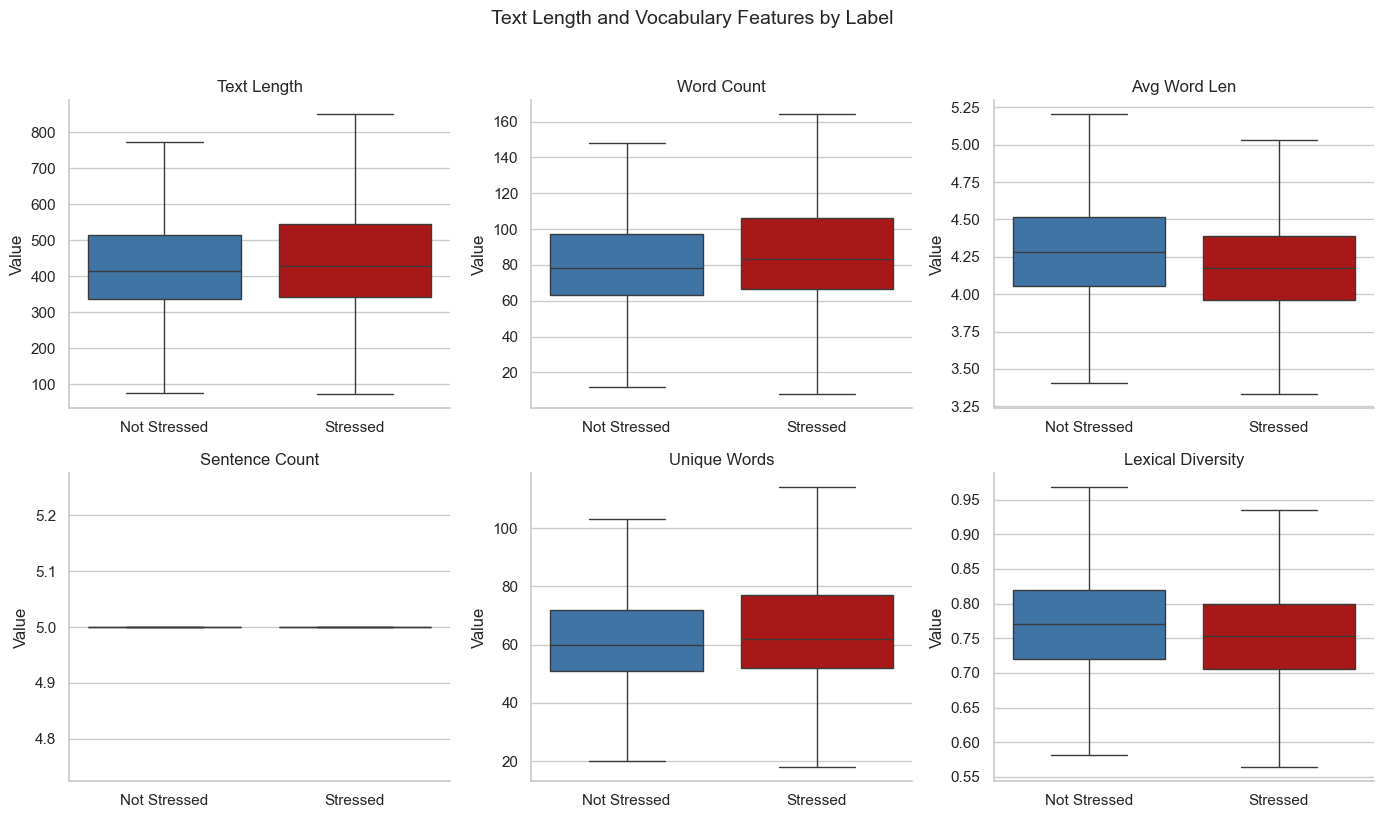

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, length_features):
    sns.boxplot(
        data=train_df,
        x='label_name',
        y=col,
        order=LABEL_ORDER,
        palette=LABEL_COLORS,
        showfliers=False,
        ax=ax
    )
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Value')

plt.suptitle('Text Length and Vocabulary Features by Label', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/text_length_features.png', dpi=150, bbox_inches='tight')
plt.show()

,question_count,exclaim_count,capital_ratio
label_name,,,
Not Stressed,0.2652,0.1785,0.0262
Stressed,0.4274,0.0813,0.0256


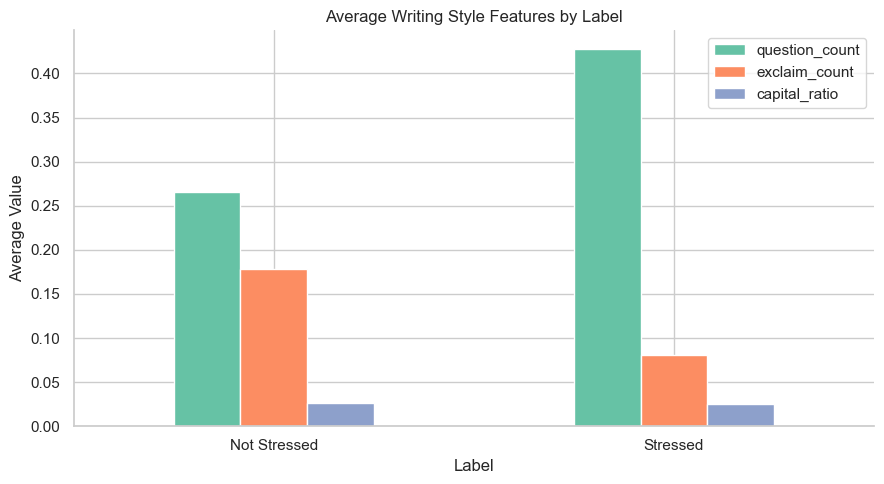

In [22]:
style_features = ['question_count', 'exclaim_count', 'capital_ratio']

style_summary = train_df.groupby('label_name')[style_features].mean().reindex(LABEL_ORDER).round(4)
display(style_summary)

style_summary.plot(kind='bar', figsize=(9, 5))
plt.title('Average Writing Style Features by Label')
plt.xlabel('Label')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/writing_style_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sentiment Analysis

Sentiment is useful because stressed posts may show more negative emotional tone.

,mean,median,std
label_name,,,
Not Stressed,0.1034,0.1072,0.1803
Stressed,-0.0161,-0.0081,0.1914


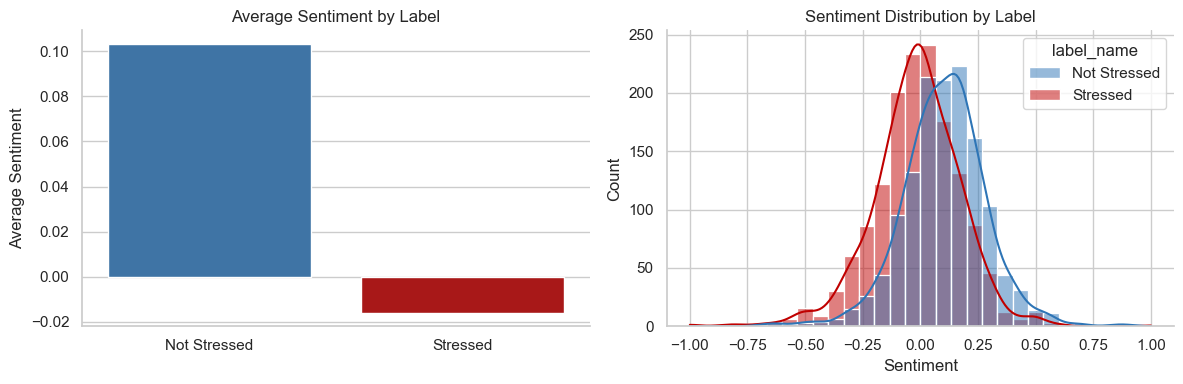

In [23]:
if train_df['sentiment'].notna().any():
    sentiment_summary = train_df.groupby('label_name')['sentiment'].agg(['mean', 'median', 'std']).reindex(LABEL_ORDER).round(4)
    display(sentiment_summary)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.barplot(
        data=train_df,
        x='label_name',
        y='sentiment',
        order=LABEL_ORDER,
        palette=LABEL_COLORS,
        errorbar=None,
        ax=axes[0]
    )
    axes[0].set_title('Average Sentiment by Label')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Average Sentiment')

    sns.histplot(
        data=train_df,
        x='sentiment',
        hue='label_name',
        hue_order=LABEL_ORDER,
        palette=LABEL_COLORS,
        kde=True,
        bins=30,
        ax=axes[1]
    )
    axes[1].set_title('Sentiment Distribution by Label')
    axes[1].set_xlabel('Sentiment')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/sentiment_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No sentiment column is available, so this section is skipped.')

## 9. Common Words and Bigrams

This section uses simple frequency counts. It is easier to explain than advanced TF-IDF feature importance.

In [24]:
def get_top_terms(df, label_value, ngram_range=(1, 1), top_n=20, min_df=2):
    texts = df.loc[df['label'] == label_value, 'text'].str.lower()

    vectorizer = CountVectorizer(
        stop_words='english',
        ngram_range=ngram_range,
        min_df=min_df,
        token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
    )

    try:
        matrix = vectorizer.fit_transform(texts)
    except ValueError:
        return pd.DataFrame(columns=['term', 'count'])

    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()

    return (
        pd.DataFrame({'term': terms, 'count': counts})
        .sort_values('count', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


top_words_not_stressed = get_top_terms(train_df, label_value=0, ngram_range=(1, 1), top_n=20)
top_words_stressed = get_top_terms(train_df, label_value=1, ngram_range=(1, 1), top_n=20)

print('Top words in not stressed posts')
display(top_words_not_stressed)

print('Top words in stressed posts')
display(top_words_stressed)

Top words in not stressed posts


,term,count
0,like,428
1,just,402
2,time,355
3,know,309
4,ve,289
5,really,278
6,don,265
7,people,259
8,years,238
9,help,234


Top words in stressed posts


,term,count
0,just,822
1,like,758
2,don,621
3,feel,575
4,know,548
5,ve,467
6,time,417
7,really,373
8,want,340
9,anxiety,314


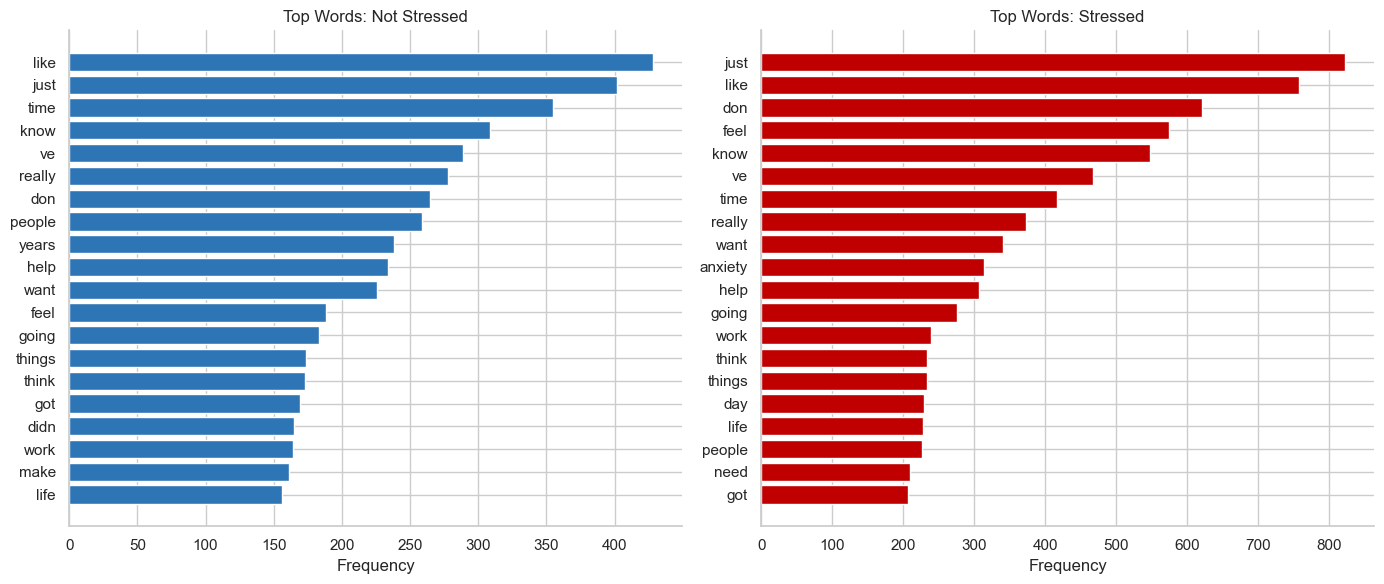

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, term_df, title, color in [
    (axes[0], top_words_not_stressed, 'Top Words: Not Stressed', LABEL_COLORS['Not Stressed']),
    (axes[1], top_words_stressed, 'Top Words: Stressed', LABEL_COLORS['Stressed'])
]:
    plot_df = term_df.sort_values('count', ascending=True)
    ax.barh(plot_df['term'], plot_df['count'], color=color)
    ax.set_title(title)
    ax.set_xlabel('Frequency')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/top_words_by_label.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
top_bigrams_not_stressed = get_top_terms(train_df, label_value=0, ngram_range=(2, 2), top_n=15)
top_bigrams_stressed = get_top_terms(train_df, label_value=1, ngram_range=(2, 2), top_n=15)

print('Top bigrams in not stressed posts')
display(top_bigrams_not_stressed)

print('Top bigrams in stressed posts')
display(top_bigrams_stressed)

Top bigrams in not stressed posts


,term,count
0,feel like,60
1,mental health,49
2,don know,42
3,years ago,39
4,don want,37
5,tl dr,34
6,let know,31
7,year old,31
8,months ago,23
9,just want,22


Top bigrams in stressed posts


,term,count
0,feel like,228
1,don know,220
2,tl dr,88
3,don want,82
4,panic attacks,40
5,just want,39
6,panic attack,35
7,just don,31
8,felt like,30
9,feels like,30


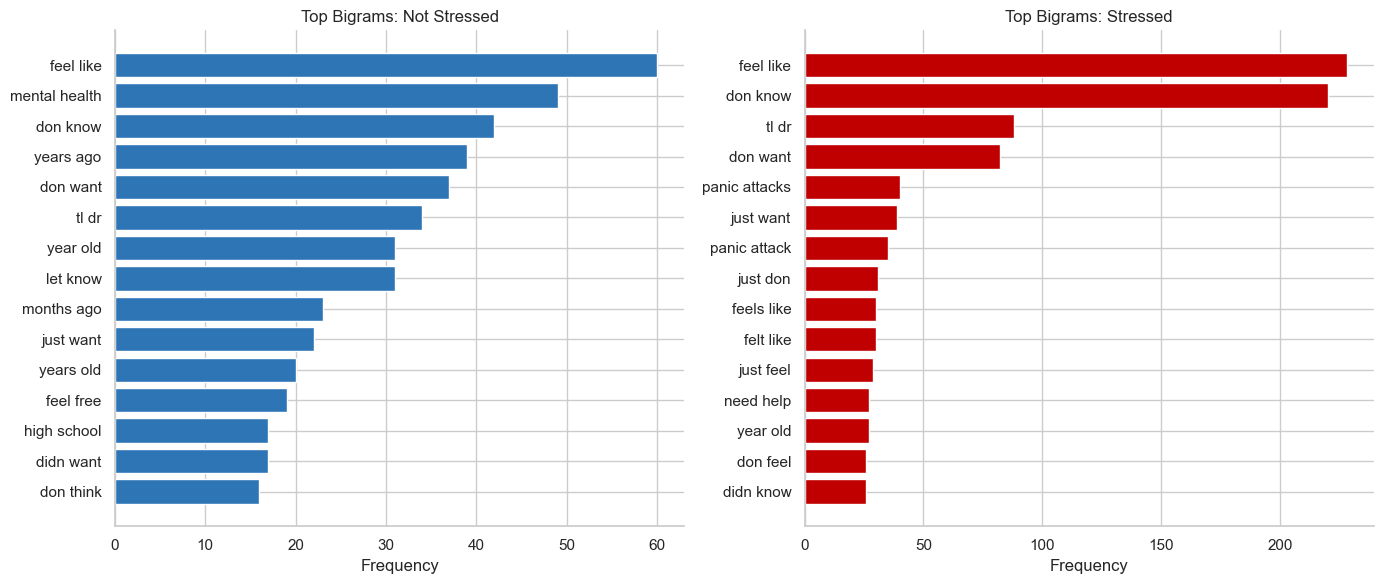

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, term_df, title, color in [
    (axes[0], top_bigrams_not_stressed, 'Top Bigrams: Not Stressed', LABEL_COLORS['Not Stressed']),
    (axes[1], top_bigrams_stressed, 'Top Bigrams: Stressed', LABEL_COLORS['Stressed'])
]:
    plot_df = term_df.sort_values('count', ascending=True)
    ax.barh(plot_df['term'], plot_df['count'], color=color)
    ax.set_title(title)
    ax.set_xlabel('Frequency')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/top_bigrams_by_label.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Simple Correlation Analysis

Correlation helps identify which numeric features are related to the stress label. This is descriptive, not proof of causation.

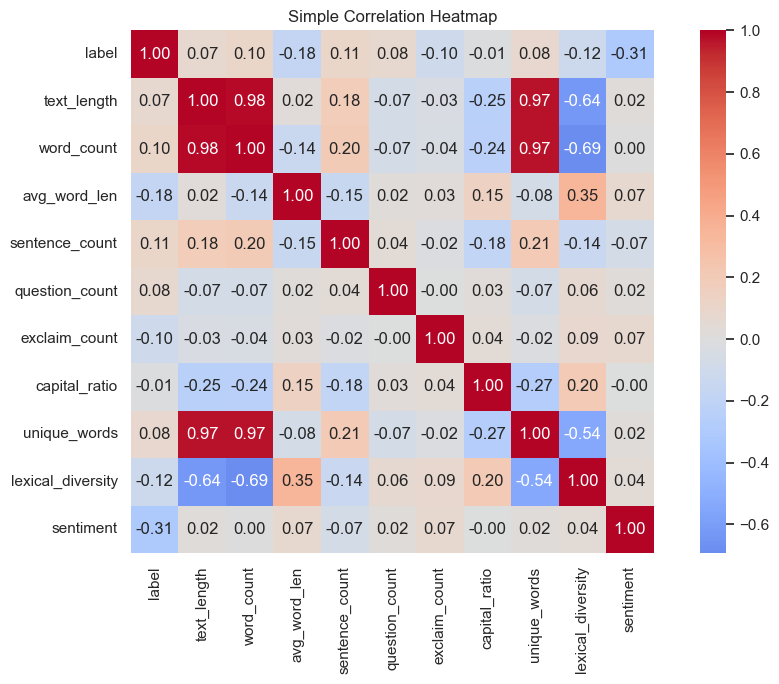

,correlation_with_label
sentiment,-0.305157
avg_word_len,-0.175955
lexical_diversity,-0.121657
sentence_count,0.106375
word_count,0.103305
exclaim_count,-0.100981
unique_words,0.084646
question_count,0.077750
text_length,0.072725
capital_ratio,-0.009444


In [28]:
correlation_cols = [
    'label', 'text_length', 'word_count', 'avg_word_len', 'sentence_count',
    'question_count', 'exclaim_count', 'capital_ratio', 'unique_words',
    'lexical_diversity'
]

if train_df['sentiment'].notna().any():
    correlation_cols.append('sentiment')

corr_matrix = train_df[correlation_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Simple Correlation Heatmap')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/simple_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

label_corr = corr_matrix['label'].drop('label').sort_values(key=lambda x: x.abs(), ascending=False)
display(label_corr.to_frame('correlation_with_label'))

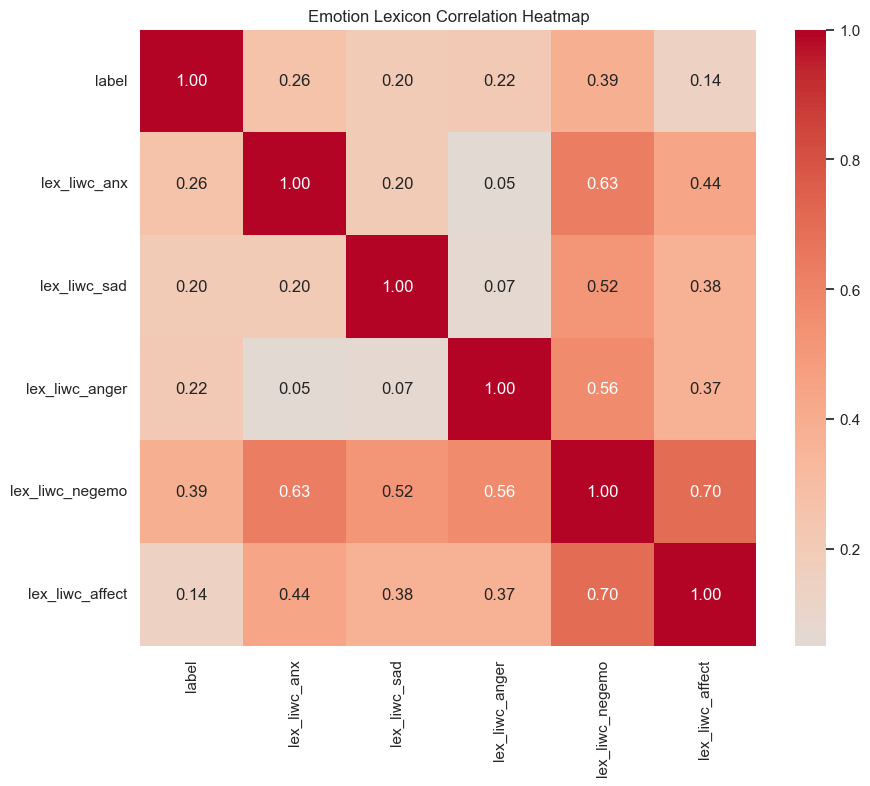

In [29]:
# Select emotion columns + label
emotion_cols = ['label', 'lex_liwc_anx', 'lex_liwc_sad', 'lex_liwc_anger', 'lex_liwc_negemo', 'lex_liwc_affect']

# Generate Square Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[emotion_cols].corr(numeric_only=True), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Emotion Lexicon Correlation Heatmap')
plt.show()

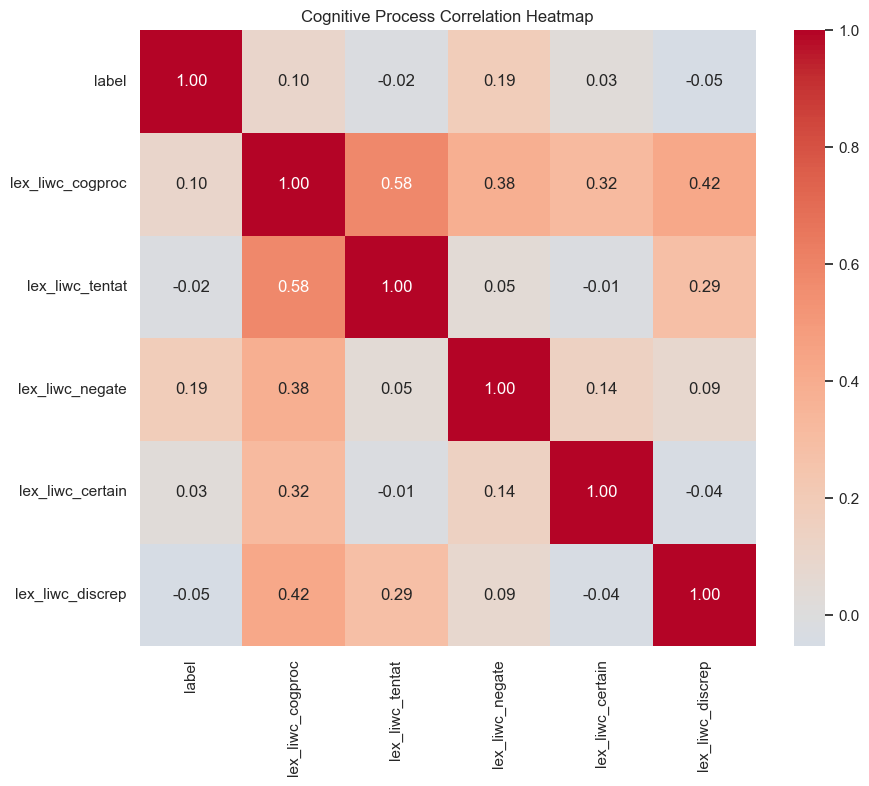

In [30]:
# Select cognitive columns + label
cognitive_cols = ['label', 'lex_liwc_cogproc', 'lex_liwc_tentat', 'lex_liwc_negate', 'lex_liwc_certain', 'lex_liwc_discrep']

plt.figure(figsize=(10, 8))
sns.heatmap(train_df[cognitive_cols].corr(numeric_only=True), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Cognitive Process Correlation Heatmap')
plt.show()

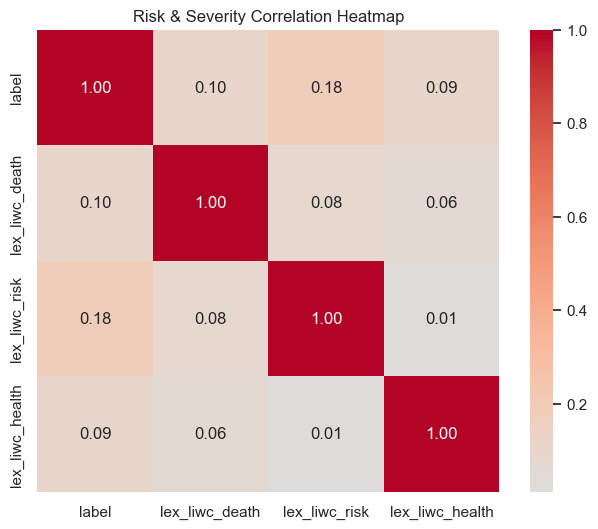

In [31]:
# Select risk columns + label
risk_cols = ['label', 'lex_liwc_death', 'lex_liwc_risk', 'lex_liwc_health']

plt.figure(figsize=(8, 6))
sns.heatmap(train_df[risk_cols].corr(numeric_only=True), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Risk & Severity Correlation Heatmap')
plt.show()

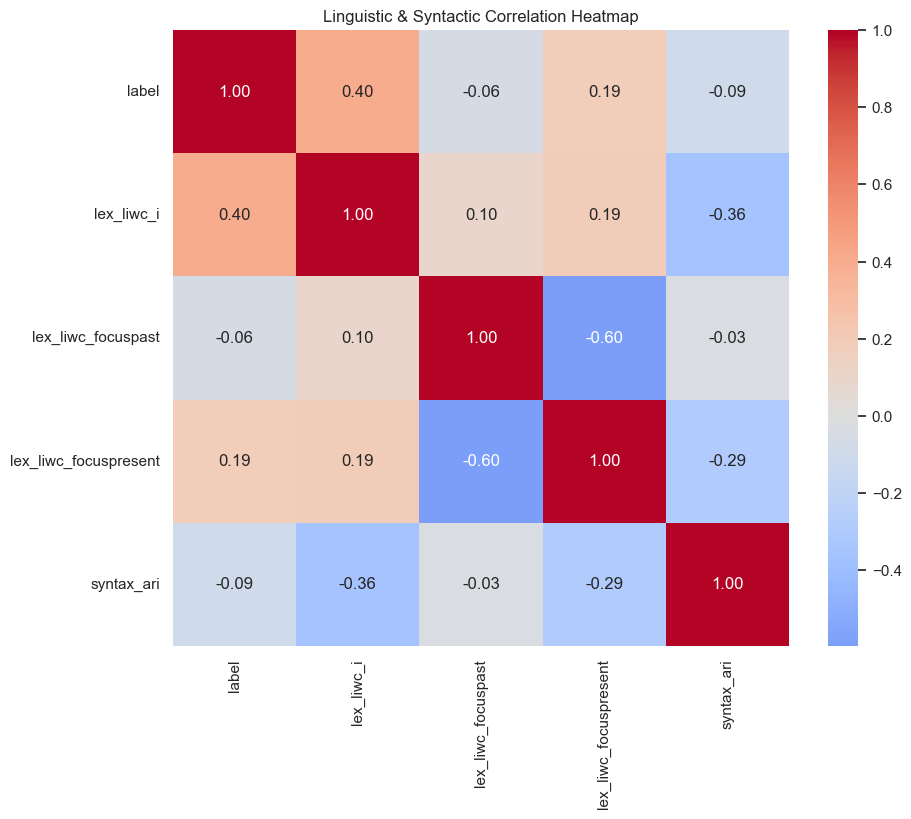

In [32]:
# Select linguistic columns + label
linguistic_cols = ['label', 'lex_liwc_i', 'lex_liwc_focuspast', 'lex_liwc_focuspresent', 'syntax_ari']

# Generate Square Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[linguistic_cols].corr(numeric_only=True), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Linguistic & Syntactic Correlation Heatmap')
plt.show()

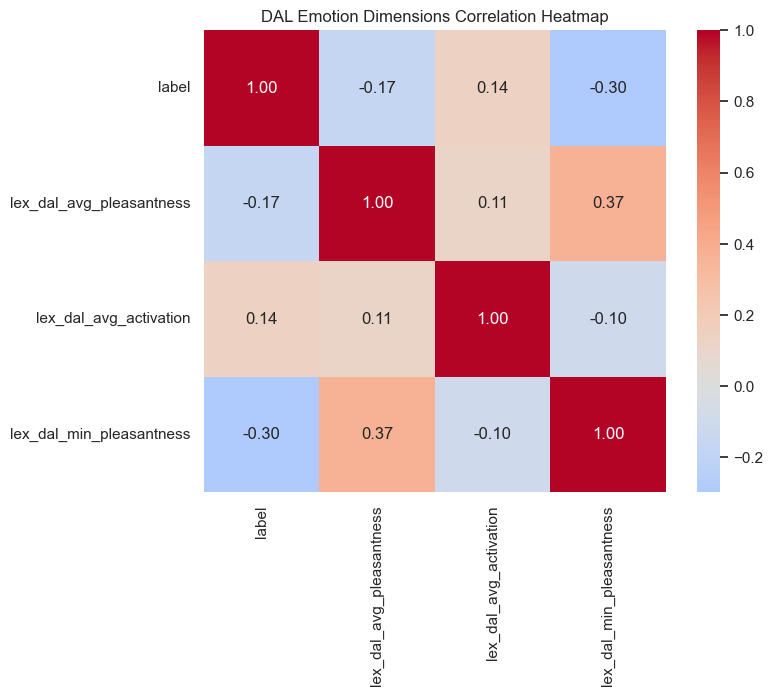

In [33]:
# Select DAL columns + label
dal_cols = ['label', 'lex_dal_avg_pleasantness', 'lex_dal_avg_activation', 'lex_dal_min_pleasantness']

# Generate Square Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[dal_cols].corr(numeric_only=True), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('DAL Emotion Dimensions Correlation Heatmap')
plt.show()

## 11. Basic Statistical Tests

Only two tests are used here to keep the analysis understandable:

1. Chi-square test: checks whether subreddit category and stress label are associated.
2. Mann-Whitney U test: checks whether word counts differ between stressed and non-stressed posts.

In [34]:
# Test 1: Chi-square test for subreddit vs stress label
contingency_table = pd.crosstab(train_df['subreddit'], train_df['label_name'])
chi2_stat, chi2_p, chi2_dof, expected = chi2_contingency(contingency_table)

print('Chi-square test: subreddit vs stress label')
print(f'Chi-square statistic: {chi2_stat:.4f}')
print(f'Degrees of freedom : {chi2_dof}')
print(f'p-value            : {chi2_p:.6f}')

if chi2_p < 0.05:
    print('Conclusion: Subreddit and stress label have a statistically significant association.')
else:
    print('Conclusion: No statistically significant association was found.')

Chi-square test: subreddit vs stress label
Chi-square statistic: 124.5007
Degrees of freedom : 9
p-value            : 0.000000
Conclusion: Subreddit and stress label have a statistically significant association.


In [35]:
# Test 2: Mann-Whitney U test for word count difference
word_count_stressed = train_df.loc[train_df['label'] == 1, 'word_count'].dropna()
word_count_not_stressed = train_df.loc[train_df['label'] == 0, 'word_count'].dropna()

mw_stat, mw_p = mannwhitneyu(word_count_stressed, word_count_not_stressed, alternative='two-sided')

print('Mann-Whitney U test: word count by stress label')
print(f'Median word count, stressed    : {word_count_stressed.median():.2f}')
print(f'Median word count, not stressed: {word_count_not_stressed.median():.2f}')
print(f'U statistic                    : {mw_stat:.4f}')
print(f'p-value                        : {mw_p:.6f}')

if mw_p < 0.05:
    print('Conclusion: Word count differs significantly between stressed and non-stressed posts.')
else:
    print('Conclusion: No significant word-count difference was found.')

Mann-Whitney U test: word count by stress label
Median word count, stressed    : 83.00
Median word count, not stressed: 78.00
U statistic                    : 1107161.5000
p-value                        : 0.000002
Conclusion: Word count differs significantly between stressed and non-stressed posts.
